# Part 2 - Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Data Loading

In [2]:
conn = sqlite3.connect("../data/reviews_analysis.db")

hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

### Convert to pandas dataframe

In [3]:
# Print our table name
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

In [4]:
# Save dataset as dictionary

# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                          str
text                           str
date_stayed                    str
hotel_id                     int64
num_helpful_votes            int64
review_date                    str
review_id                    int64
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_id                      str
dtype: object

Table name:   authors
id                       str
username                 str
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
location                 str
alias                    str
dtype: object

Table name:   hotels
hotel_id                         int64
num

Most of the features name and data dtype looks correct except for the date. So the following code is to cast the date to pandas datetime.

### Converting stayed_at to datetime

In [7]:
dataset['reviews']

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Big Disappointment!”,Since we have not traveled to San Francisco in...,October 2012,81416,2,2012-10-29,143991612,0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,FACBB67C723ECE716ACDB472DCBD9D4F
1,“Very impressed!!”,We stayed on the 4th floor facing the road in ...,November 2011,2154898,0,2011-11-26,121053587,1,5.0,5.0,5.0,5.0,4.0,NaN,5.0,NaN,NaN,A9FCDC34F83B95023BFEE83D29D67242
2,“Near pefection”,"Fantastic. As a world traveler, I have stayed ...",April 2012,665258,0,2012-05-16,130065325,0,5.0,4.0,5.0,4.0,3.0,5.0,5.0,NaN,NaN,BCB73643A2D21CA89A7DD2CB23D3F95B
3,“Excellent Bar Staff”,The Polar Bar staff is the best in the country...,February 2012,677260,0,2012-02-21,125001925,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,NaN
4,“Naja”,Wir hatten für 3 Nächte 2 Zimmer gebucht. Die ...,February 2010,113923,0,2010-02-23,56889304,0,3.0,3.0,3.0,3.0,5.0,3.0,4.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,“Centrally located Ageing Hotel”,The hotel is in a downtown location and is wit...,October 2012,89602,0,2012-10-10,142516580,0,3.0,3.0,3.0,2.0,4.0,2.0,3.0,NaN,NaN,NaN
79996,"“Very nice, but imperfect”",The room was very quiet - too quiet! Even the ...,September 2010,89585,0,2010-09-15,79670549,0,5.0,5.0,4.0,3.0,5.0,4.0,4.0,NaN,NaN,NaN
79997,“Great Value”,Totally recommend this place. Got a great nigh...,October 2012,226753,0,2012-10-24,143602018,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,0729D497869DDFB481E90869F4E8A1F7
79998,“Doing things right”,Just got back from a great NYC long weekend. T...,December 2012,1456411,0,2012-12-12,147288297,0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,NaN,NaN,096E47AEB7782F6E3ACE5A0AC81B84FA


In [8]:
dataset['reviews']['date_stayed'] = pd.to_datetime(
    dataset['reviews']['date_stayed'],
    format='%B %Y',
    errors='coerce'
)
dataset['reviews']['review_date'] = pd.to_datetime(
    dataset['reviews']['review_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [9]:
dataset['reviews']['date_stayed'].isna().sum()
dataset['reviews'].dropna(subset='date_stayed', inplace=True)

In [10]:
print(f'length of data: {len(dataset['reviews'])}')

length of data: 79997


In [11]:
print(dataset['reviews']['review_date'].min())
print(dataset['reviews']['review_date'].max())

reviews_df = dataset['reviews']

filtered = reviews_df[reviews_df['review_date'] - reviews_df['date_stayed'] <= pd.Timedelta(days=150)]
print(f'length of data: {len(filtered)}')

2008-01-01 00:00:00
2012-12-20 00:00:00
length of data: 74117


The dates data are not in the right type, so we must parse it.
These are some notable warnings that I noticed:
* date_stayed = should be in date (only the year and month that is important)
* review_date = should be in date (full format)


In [12]:
# Converting date_stayed to a date format
dataset['reviews']['date_stayed_dt'] = pd.to_datetime(dataset['reviews']['date_stayed'], format='%B %Y')

# Converting review_date to a date format
dataset['reviews']['review_date'] = pd.to_datetime(dataset['reviews']['review_date'])

In [13]:

print(f'\nTable name:   reviews')
print(f'{dataset['reviews'].dtypes}')


Table name:   reviews
title                                 str
text                                  str
date_stayed                datetime64[us]
hotel_id                            int64
num_helpful_votes                   int64
review_date                datetime64[us]
review_id                           int64
via_mobile                          int64
service_rating                    float64
cleanliness_rating                float64
overall_rating                    float64
value_rating                      float64
location_rating                   float64
sleep_quality_rating              float64
rooms_rating                      float64
check_in_service_rating           float64
business_service_rating           float64
author_id                             str
date_stayed_dt             datetime64[us]
dtype: object


---

## 2. Data Exploration & Feature Engineering

### Reviews table

In [14]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt
0,“Big Disappointment!”,Since we have not traveled to San Francisco in...,2012-10-01,81416,2,2012-10-29,143991612,0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,FACBB67C723ECE716ACDB472DCBD9D4F,2012-10-01
1,“Very impressed!!”,We stayed on the 4th floor facing the road in ...,2011-11-01,2154898,0,2011-11-26,121053587,1,5.0,5.0,5.0,5.0,4.0,NaN,5.0,NaN,NaN,A9FCDC34F83B95023BFEE83D29D67242,2011-11-01
2,“Near pefection”,"Fantastic. As a world traveler, I have stayed ...",2012-04-01,665258,0,2012-05-16,130065325,0,5.0,4.0,5.0,4.0,3.0,5.0,5.0,NaN,NaN,BCB73643A2D21CA89A7DD2CB23D3F95B,2012-04-01
3,“Excellent Bar Staff”,The Polar Bar staff is the best in the country...,2012-02-01,677260,0,2012-02-21,125001925,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,NaN,2012-02-01
4,“Naja”,Wir hatten für 3 Nächte 2 Zimmer gebucht. Die ...,2010-02-01,113923,0,2010-02-23,56889304,0,3.0,3.0,3.0,3.0,5.0,3.0,4.0,NaN,NaN,NaN,2010-02-01


In [15]:
print(f'Reviews table has {len(reviews_df)} entries.')

reviews_df[reviews_df['date_stayed_dt'] == '2003-09-01']

Reviews table has 79997 entries.


,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt
3377,“Best bed ever”,The W in Seattle had the best bed ever - it wa...,2003-09-01,100586,2,2008-08-25,19327745,0,4.0,5.0,5.0,5.0,4.0,NaN,5.0,5.0,NaN,NaN,2003-09-01
57219,“good value”,Stayed here with my brother to watch the US Op...,2003-09-01,93579,1,2008-10-02,20547143,0,5.0,3.0,4.0,5.0,5.0,NaN,3.0,5.0,NaN,368236F50751D53ADBC594BF3167C0DC,2003-09-01


The customer stayed on September 2003, but the review was given on 25 August 2008 which is about 5 years later. This data seems a little but irrelevant. There for we should check for the rest of the data, as there may be some wrong entries where the review_date is even earlier than the date_stayed.

In [16]:
# Check for data where review_date is earlier than date_stayed_dt
invalid_entries = reviews_df[reviews_df['review_date'] < reviews_df['date_stayed_dt']].index
reviews_df.drop(invalid_entries,inplace=True)

print(f'Number of invalid data: {len(invalid_entries):,} entries')
print(f'Number of entries after removal: {len(reviews_df):,} entries')
# invalid_entries

Number of invalid data: 29 entries
Number of entries after removal: 79,968 entries


Now that the data date is valid, we can add new feature called 'review_days_since_stay' that denotes how long the review is given after the stay date.

In [17]:
reviews_df['reviews_days_since_stay'] = reviews_df['review_date'] - reviews_df['date_stayed_dt']
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt,reviews_days_since_stay
0,“Big Disappointment!”,Since we have not traveled to San Francisco in...,2012-10-01,81416,2,2012-10-29,143991612,0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,FACBB67C723ECE716ACDB472DCBD9D4F,2012-10-01,28 days
1,“Very impressed!!”,We stayed on the 4th floor facing the road in ...,2011-11-01,2154898,0,2011-11-26,121053587,1,5.0,5.0,5.0,5.0,4.0,NaN,5.0,NaN,NaN,A9FCDC34F83B95023BFEE83D29D67242,2011-11-01,25 days


In [18]:
# Date
# reviews_df['review_date', 'date_stayed_dt']
print('======== DATE ANALYSIS ========')
print(f'date_stayed date range:    {reviews_df['date_stayed_dt'].min().strftime('%B %Y')} - {reviews_df['date_stayed_dt'].max().strftime('%B %Y')}')
print(f'review_date date range:    {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}')

======== DATE ANALYSIS ========
date_stayed date range:    February 2003 - December 2012
review_date date range:    1 January 2008 - 20 December 2012


In [19]:
# Categorical
print('======== CATEGORICAL ANALYSIS ========')
print(f'- {reviews_df['via_mobile'].mean():.2%} of people fill the review via mobile')

for col in ['service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']:
    print(f'\n- {col} average of all hotel is {reviews_df[col].mean():.1f} stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 5]) / len(reviews_df)):.2%} of the rating is 5 stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 1]) / len(reviews_df)):.2%} of the rating is 1 stars')
    
    nan_count = reviews_df[col].isna().sum()
    if nan_count > 0:
        print(f'    - {(nan_count / len(reviews_df)):.2%} ({nan_count} entries) does not give any rating')

reviews_df[[
    'via_mobile',
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
    ]].describe()


======== CATEGORICAL ANALYSIS ========
- 6.52% of people fill the review via mobile

- service_rating average of all hotel is 4.1 stars
    - 51.00% of the rating is 5 stars
    - 5.52% of the rating is 1 stars

- cleanliness_rating average of all hotel is 4.2 stars
    - 54.67% of the rating is 5 stars
    - 3.80% of the rating is 1 stars

- overall_rating average of all hotel is 4.0 stars
    - 41.65% of the rating is 5 stars
    - 5.00% of the rating is 1 stars

- value_rating average of all hotel is 3.9 stars
    - 40.10% of the rating is 5 stars
    - 5.65% of the rating is 1 stars

- location_rating average of all hotel is 4.4 stars
    - 62.14% of the rating is 5 stars
    - 1.62% of the rating is 1 stars

- sleep_quality_rating average of all hotel is 4.1 stars
    - 35.24% of the rating is 5 stars
    - 3.53% of the rating is 1 stars
    - 27.14% (21707 entries) does not give any rating

- rooms_rating average of all hotel is 4.0 stars
    - 40.75% of the rating is 5 stars
   

,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
count,79968.000000,79968.000000,79968.000000,79968.000000,79968.000000,79968.000000,58261.000000,79968.000000,6381.000000,4313.000000
mean,0.065239,4.109781,4.242985,4.005090,3.926833,4.428046,4.106589,3.960834,4.010186,3.675400
std,0.246948,1.154379,1.048677,1.117073,1.156422,0.881317,1.111560,1.130628,1.185488,1.234699
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,3.000000
50%,0.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000
75%,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [20]:
# Numerical
print('======== NUMERICAL ANALYSIS ========')
reviews_df[[
    'num_helpful_votes'
    ]].describe()

======== NUMERICAL ANALYSIS ========


,num_helpful_votes
count,79968.000000
mean,0.631478
std,1.241735
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,74.000000


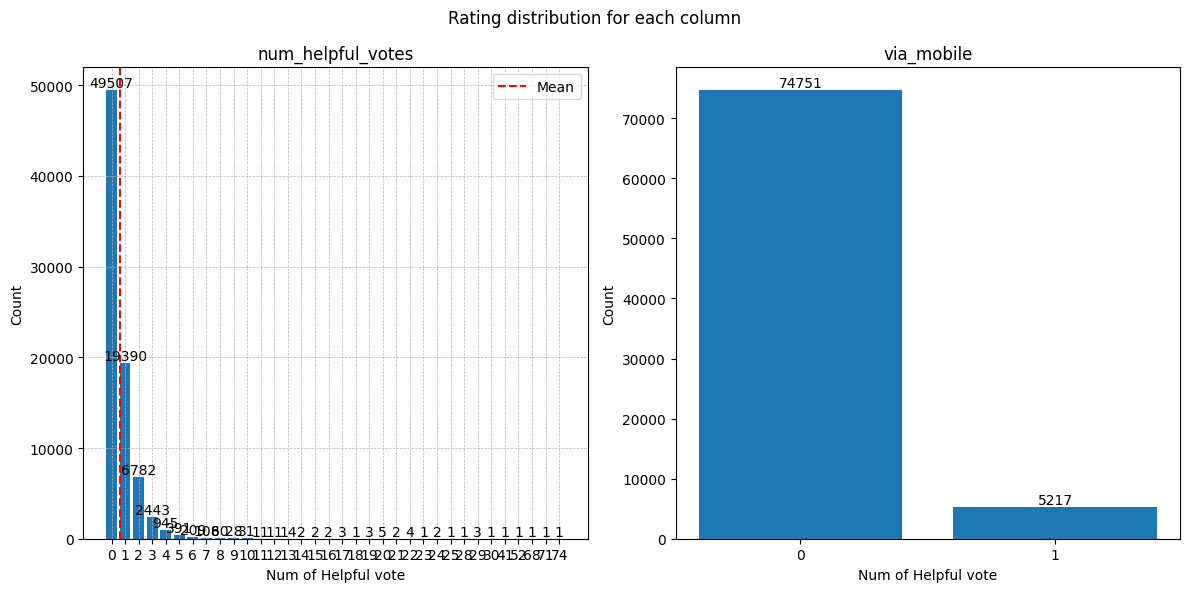

In [21]:
rating_column = [
    'num_helpful_votes',
    'via_mobile',
]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))
    
    
    bars = ax[i].bar(counts.index, counts.values)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    if col == 'num_helpful_votes':
        ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Num of Helpful vote')
    ax[i].set_ylabel('Count')

ax[0].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column')
plt.tight_layout()
plt.show()

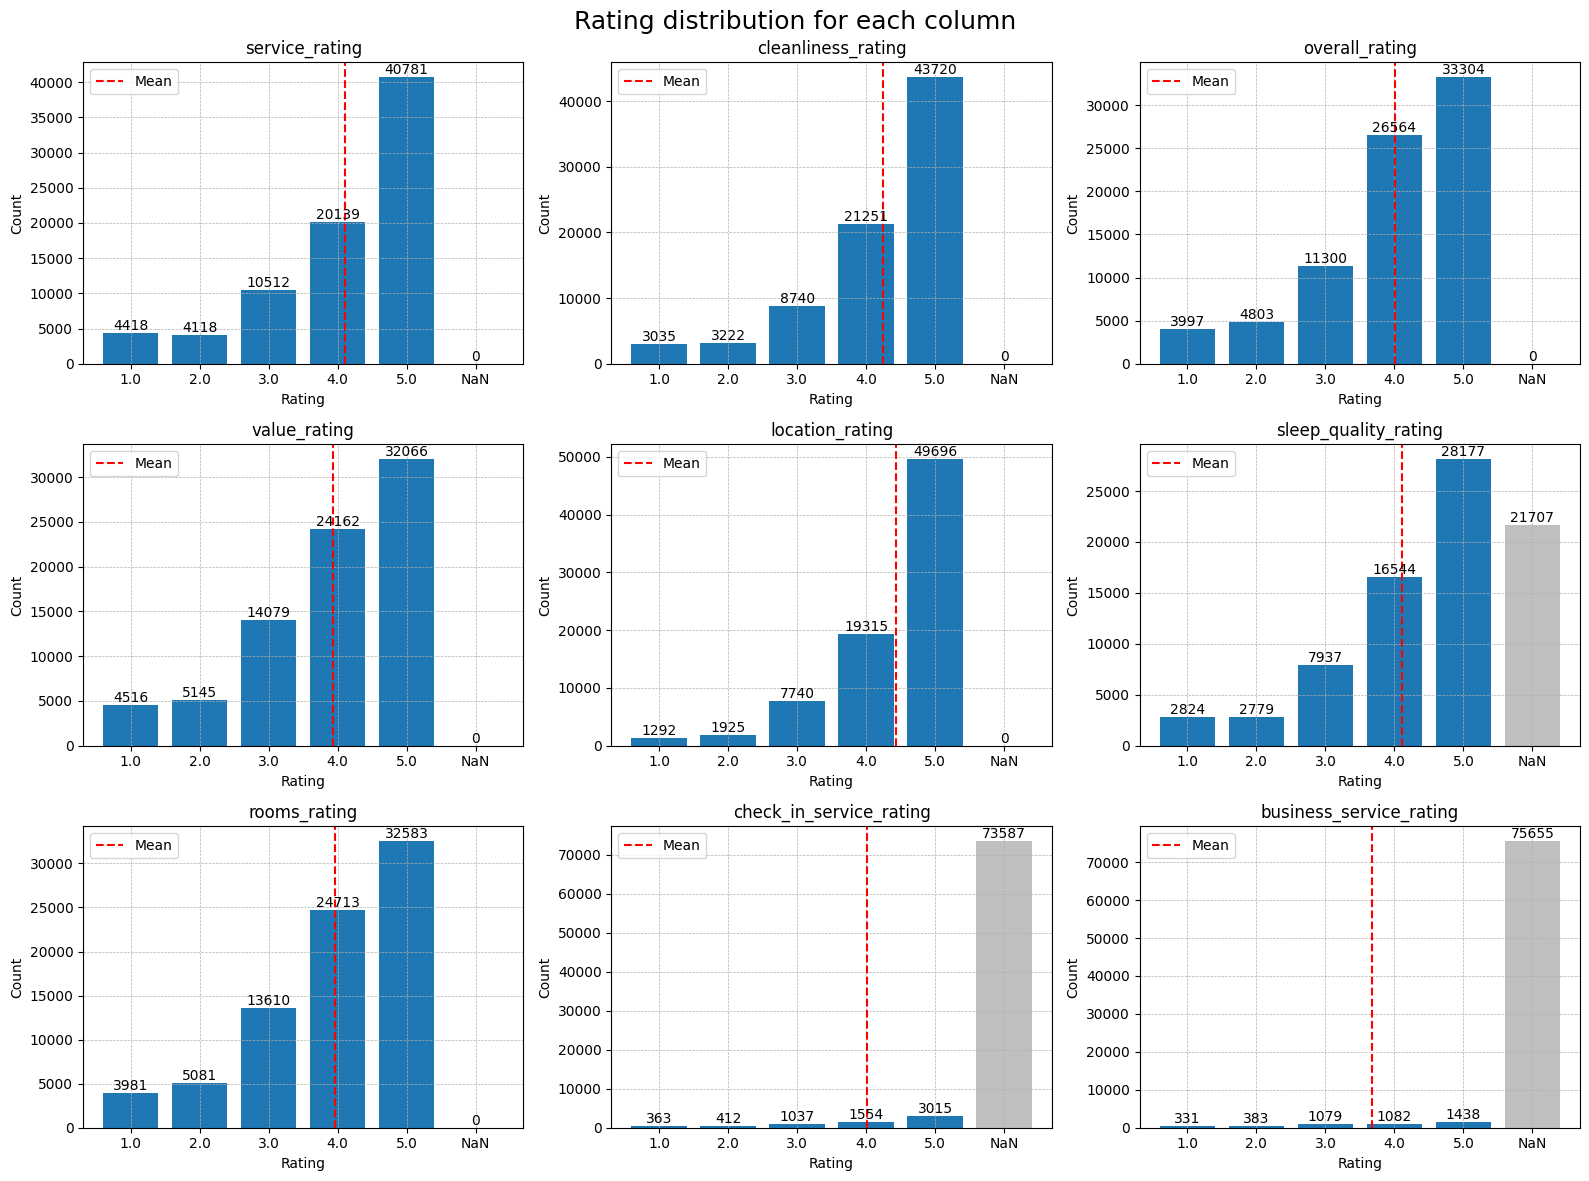

In [22]:
rating_column = [
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
]

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

### Authors Table

In [23]:
authors_df = dataset['authors']
authors_df.head()

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",
2,F2CF681476F8394CB7D0CC20CF7C054F,akovalcsik,85.0,130.0,748.0,22.0,"Boston, Massachusetts",
3,A0AA9179916CE2722C87F85CA42B0B40,AdelaidianTraveller,135.0,609.0,738.0,50.0,Adelaide Australia,
4,3F75FA2DE3464A75D56B30470C0EA060,tymetraveler222,217.0,NaN,701.0,100.0,"Bay City, Michigan",


In [24]:
print(f'Number of entries in the authors dataframe: {len(authors_df):,} entries')

authors_df['num_reviews'].sum()
print('ALERT!!! Number of reviews in total are 101,958 but the reviews_sample.db that i am using only has 6,000. this data should not be available in real scenario, might cause data leakage')

Number of entries in the authors dataframe: 576,687 entries
ALERT!!! Number of reviews in total are 101,958 but the reviews_sample.db that i am using only has 6,000. this data should not be available in real scenario, might cause data leakage


In [25]:
authors_df.describe()

,num_cities,num_helpful_votes,num_reviews,num_type_reviews
count,394266.000000,436231.000000,576634.000000,300525.000000
mean,9.277006,13.230270,11.116819,9.986504
std,10.177852,25.343781,18.904046,10.556904
min,2.000000,1.000000,1.000000,3.000000
25%,3.000000,2.000000,1.000000,4.000000
50%,6.000000,6.000000,4.000000,7.000000
75%,12.000000,14.000000,13.000000,12.000000
max,284.000000,964.000000,935.000000,330.000000


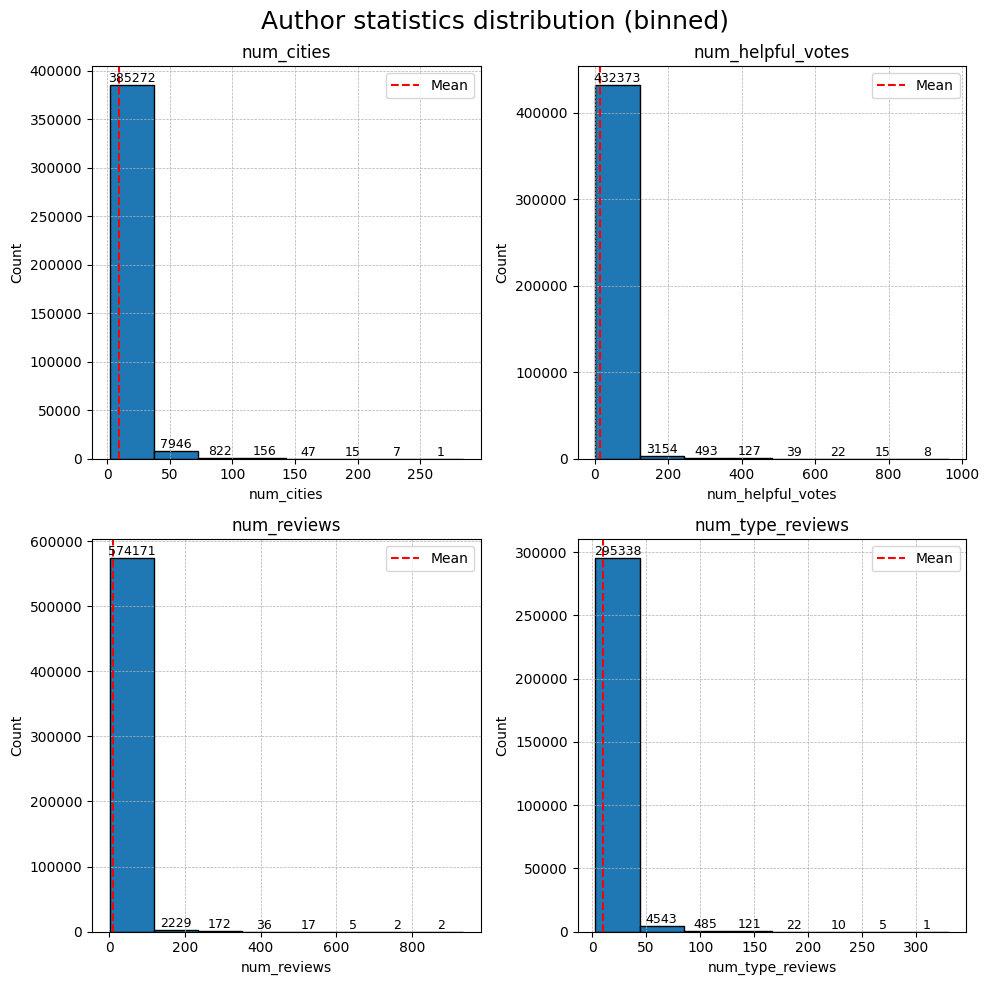

In [26]:
author_column = [
    'num_cities',
    'num_helpful_votes',
    'num_reviews',
    'num_type_reviews'
]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax = ax.flatten()

for i, col in enumerate(author_column):
    mean = authors_df[col].mean()
    
    authors_df_filled = authors_df[col].fillna('NaN').astype(str)
    counts = authors_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax[i].hist(
        authors_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax[i].text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
    ax[i].legend()

    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle='--', linewidth=0.5)

plt.suptitle('Author statistics distribution (binned)', fontsize=18)
plt.tight_layout()
plt.show()

### Hotels table

In [27]:
hotels_df = dataset['hotels']
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
0,214197,2624,2.399390,2.342226,2.363567,2.737805,4.492759,2.682187,2.131479,2.434599,2.344156
1,122005,2395,3.908559,4.206681,3.983299,3.886013,4.691441,4.117004,3.720251,3.673077,3.768116
2,93618,2300,4.015652,4.141304,3.899565,3.456957,4.634783,4.149271,3.744783,4.163842,3.580000
3,93520,2168,3.518450,3.622694,3.588561,3.588100,4.696033,3.838451,3.499077,3.025000,2.697248
4,93562,2044,4.235323,4.213307,4.088063,4.014677,4.684932,3.942877,4.002935,4.350394,3.758389


num_reviews


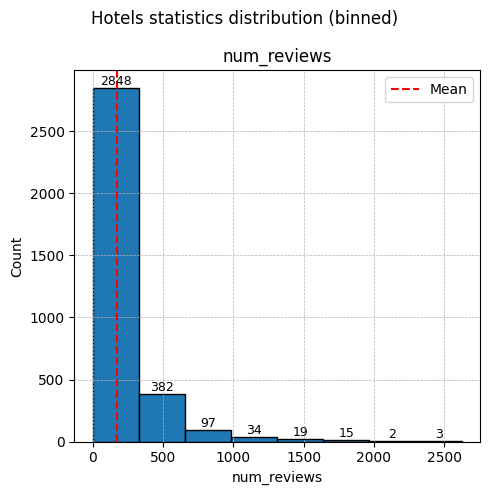

In [28]:
hotel_column = [
    'num_reviews',
]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

for i, col in enumerate(hotel_column):
    print(col)
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax.hist(
        hotels_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax.axvline(mean, color='red', linestyle='--', label='Mean')
    ax.legend()

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(linestyle='--', linewidth=0.5)

plt.suptitle('Hotels statistics distribution (binned)')
plt.tight_layout()
plt.show()

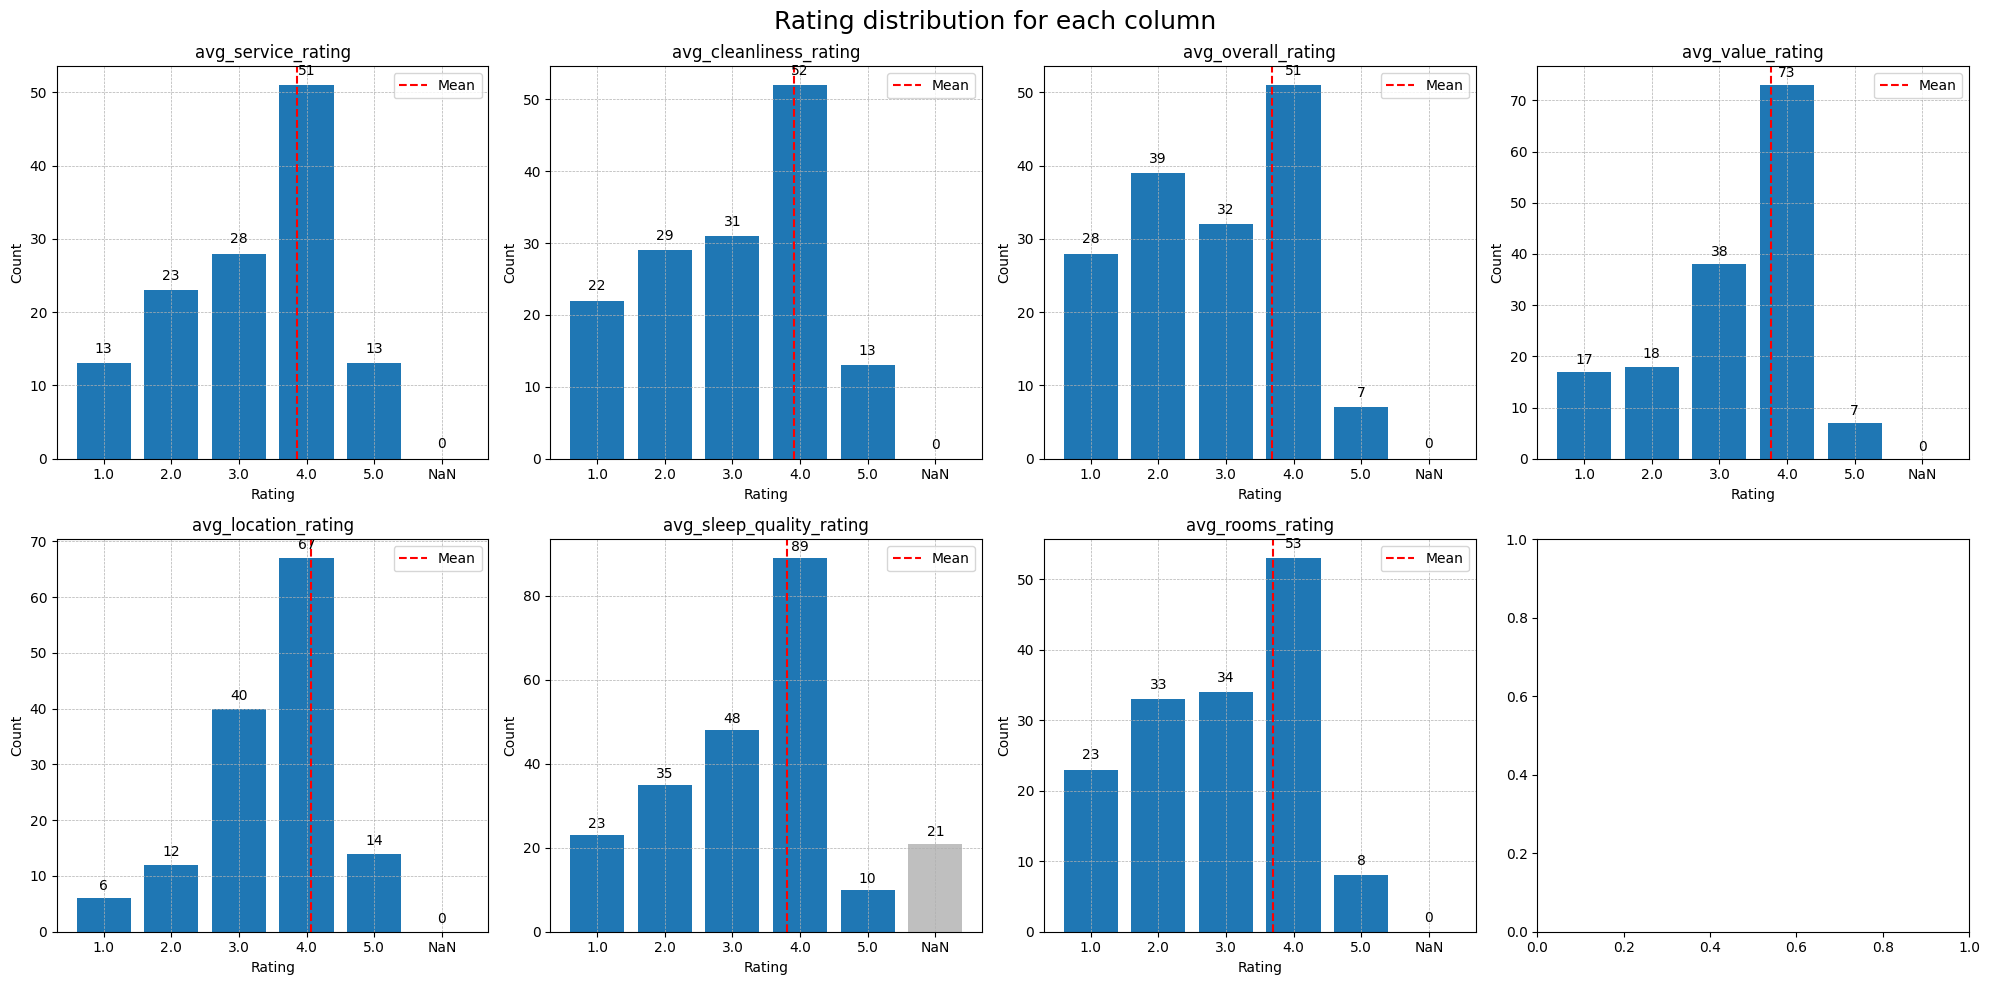

In [29]:
hotel_column = [
    'avg_service_rating',
    'avg_cleanliness_rating',
    'avg_overall_rating',
    'avg_value_rating',
    'avg_location_rating',
    'avg_sleep_quality_rating',
    'avg_rooms_rating',
]

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10))
ax = ax.flatten()

for i, col in enumerate(hotel_column):
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    # x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    # x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

---

## 3. Feature Engineering

### **review_frequency** (authors_df)

Whether an author frequently write reviews compared to the median of all authors.

In [30]:
authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",


We need to check the skewness of the data before doing the threshold, therefore let's visualize the feature

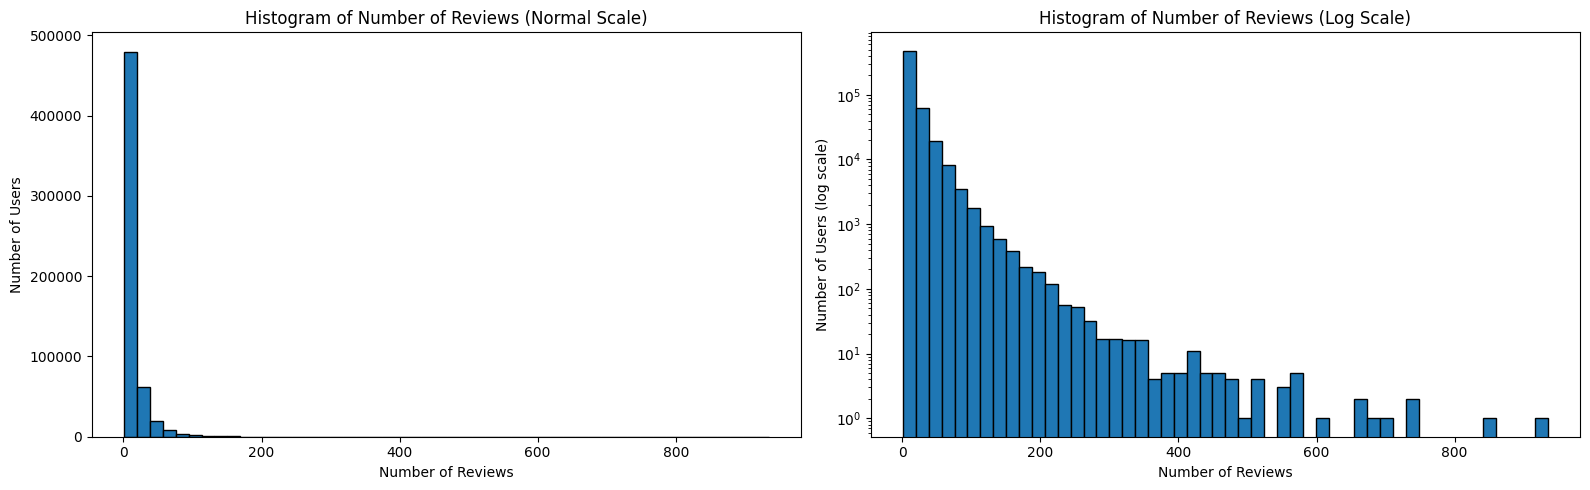

In [31]:
authors_df['num_reviews'].value_counts()

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Normal scale histogram
axes[0].hist(authors_df['num_reviews'], bins=50, edgecolor='black')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Histogram of Number of Reviews (Normal Scale)')

# Log scale histogram
axes[1].hist(authors_df['num_reviews'], bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('Histogram of Number of Reviews (Log Scale)')

plt.tight_layout()
plt.show()


The heavy skewness makes it hard to use simple thresholding with mean, std, or median. Our approach will use the quantile based categorization so that we have a balanced category.

In [32]:
# Set the quantile
q1 = authors_df['num_reviews'].quantile(0.33)
q2 = authors_df['num_reviews'].quantile(0.66)

print('=' * 40)
print('category')
print('=' * 40)
print(f'range from 0 - {q1} ===> Low')
print(f'range from {q1} - {q2} ===> Medium')
print(f'range from {q2} - infinity ===> High')
print('=' * 40)

def categorize_reviews(n):
    if n <= q1:
        return 'low'
    elif n <= q2:
        return 'medium'
    else:
        return 'high'

authors_df['review_frequency'] = authors_df['num_reviews'].apply(categorize_reviews)

category
range from 0 - 2.0 ===> Low
range from 2.0 - 9.0 ===> Medium
range from 9.0 - infinity ===> High


In [33]:
for freq in ['low', 'medium', 'high']:
    print(f'{freq.upper()} frequency total: {len(authors_df[authors_df['review_frequency'] == freq]):,}')

LOW frequency total: 222,321
MEDIUM frequency total: 168,272
HIGH frequency total: 186,094


In [34]:
# IF USING MEAN STD OR MEDIAN
freq_df = authors_df.copy()

mean = freq_df['num_reviews'].mean()
median = freq_df['num_reviews'].median()
std = freq_df['num_reviews'].std()

freq_df['freq_mean'] = freq_df['num_reviews'] > mean
freq_df['freq_mean_std'] = freq_df['num_reviews'] > (mean + std)
freq_df['freq_median'] = freq_df['num_reviews'] > median

for freq in ['freq_mean', 'freq_mean_std', 'freq_median']:
    print(f'\n{freq}')
    print(f'frequent: {freq_df[freq].sum():,}')
    print(f'not frequent: {len(freq_df) - (freq_df[freq].sum()):,}')


freq_mean
frequent: 161,642
not frequent: 415,045

freq_mean_std
frequent: 51,690
not frequent: 524,997

freq_median
frequent: 281,716
not frequent: 294,971


Using the mean and std will make the class very unstable.

Using median might be a good choice, but it will only allow binary categorization instead of multi level category.

In [35]:
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency
127498,333D9E7A74D0B0CFBABC8460A24C716D,Edythe,13.0,18.0,15.0,14.0,Edmonton,,high
521198,783C70A8938BECFAB5130660D959B7BF,Glenda N,NaN,4.0,1.0,NaN,"Sonora, California",,low
571221,B729DCDB90197E71AE4F713772CB38F8,travellady1959,NaN,NaN,1.0,NaN,"Miami, Florida",,low
314978,E007BF544B31425AB1ADFF0365176F6D,JMcFe,2.0,17.0,3.0,3.0,"Tuscaloosa, Alabama",,medium
475933,69882C34DEC25F0088F7866BE1BB6997,mellmontreal,NaN,NaN,1.0,NaN,"Montreal, Canada",,low
411045,02782E12A2E62F7AEC7B7FC56C7724BA,Hidngplace,2.0,4.0,2.0,NaN,"Henderson, Texas",,low
182784,D9EAF5A4592B70E766CBF4355108B4B2,beachh2o,4.0,NaN,10.0,4.0,FLORIDA,,high
296212,883FAB50659E9619DD05C89A2DEA008D,Pocahontas57,3.0,1.0,4.0,3.0,,,medium
503464,7A4A5CB5B4DBD3938E38A4F3CC6AE49A,GreenBayPacker,NaN,NaN,1.0,NaN,Green Bay,,low
54339,044E0734153DF6660DAAB2837915CA1B,Valéria S,8.0,9.0,30.0,7.0,"Recife, PE",,high


**helpful_votes_per_review** in the authors_df

**avg_stars_given** in the authors_df

**ratings_variance** in the hotels_df to make sure the rating is consistent

**distance_from_avg** in the reviews_df ratings

---

## 4. Analytics by Business Questions

### **a. How does the hotel rating differ by location?**

ALERT!!! Location is not in the hotels_df

### **b. Best and worst hotels from each service category?**

### **c. Repeating visitor? mobile vs non mobile? fast and late review (3 mos threshold)?**

### **d. Best compliment Keyword for each hotels?**

My idea is to normalize the reviews, and check using tf-idf

In [36]:
#

### **e. Which rating category contributes the most to the overall rating?**

check the correlation of the scores. this can help the hotel to decide where to invest next

### **f. Trend in the stars during the years for each hotel or for each location group**

### **g. "How does my hotel perform?"**

by inputting the average rating of the current hotel, we can show graph like "you perform better than 90% of hotels worldwide, and 95% in the same region".

### **h. top 5 hotel and bottom 5 hotel per location**

### **i. best and worst service per location to tell which countries are better in certain category**

### **j. does mobile reviews is shorter and less helpful?**

### **k. Do fast reviews tend to be more negative?**

### **l. are experienced travelers more critical than casual reviewers?**

---

Column Explanation:
* title
* text
* date_stayed
* hotel_id
* num_helpful_votes
* review_date
* review_id
* via_mobile
* service_rating
* cleanliness_rating
* overall_rating
* value_rating
* location_rating
* sleep_quality_rating
* rooms_rating
* check_in_service_rating
* business_service_rating
* author_key

### Close connection

In [37]:
conn.close()

Issue:
- is the location denotes the hotel's location or the user
- where is the complete dataset .db
- data validation step is still incomplete (date checking and else)
- column description step is missing yet essential for us to make
- feature engineering part needs more ideas